In [ ]:
# !pip install minisom



import pandas as pd
from sentence_transformers import SentenceTransformer
from minisom import MiniSom
import matplotlib.pyplot as plt
import numpy as np
import re


# Load the dataset
df = pd.read_csv('tweets.csv', encoding='ISO-8859-1')

# Define columns
tweet_column = 'text'
class_column = 'handle'

# Tokenization function
def tokenize(text):
  return re.findall(r'\b\w+\b', str(text).lower())

# Calculate tweet lengths
tweet_lengths = df[tweet_column].apply(lambda x: len(tokenize(x)))

# Plot both distributions side by side
plt.figure(figsize=(14, 6))

# Plot tweet length distribution
plt.subplot(1, 2, 1)
plt.hist(tweet_lengths, bins=range(1, max(tweet_lengths) + 2), edgecolor='black')
plt.title('Distribution of Tweet Lengths (Number of Tokens)')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.xticks(range(1, max(tweet_lengths) + 1), rotation=90)

# Plot class distribution
plt.subplot(1, 2, 2)
class_counts = df[class_column].value_counts()
bars = plt.bar(class_counts.index, class_counts.values, edgecolor='black')
plt.title('Distribution of Class Column')
plt.xlabel('Class')
plt.ylabel('Frequency')

# Add counts below each bar
for bar in bars:
  height = bar.get_height()
  plt.text(bar.get_x() + bar.get_width() / 2, height - 5, str(int(height)), ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

In [ ]:
texts = df['text'].tolist()
labels = df['handle'].tolist()

In [ ]:
# Step 2: BERT Embeddings
# model = SentenceTransformer('all-MiniLM-L6-v2')
# Examples
model = SentenceTransformer("distilbert-base-nli-mean-tokens")    # DistilBERT
# model = SentenceTransformer("roberta-base-nli-stsb-mean-tokens")  # RoBERTa
# model = SentenceTransformer("sentence-transformers/electra-base-discriminator")  # Electra

# Generate embeddings
embeddings = model.encode(texts, show_progress_bar=True)

# Step 3: Train SOM
som_size = 10  # 10x10 grid
som = MiniSom(som_size, som_size, embeddings.shape[1], sigma=0.5, learning_rate=0.5)
som.random_weights_init(embeddings)
som.train_random(embeddings, 1000)  # Train for 1000 iterations


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.80k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/202 [00:00<?, ?it/s]

In [ ]:
embeddings.shape[1]

768

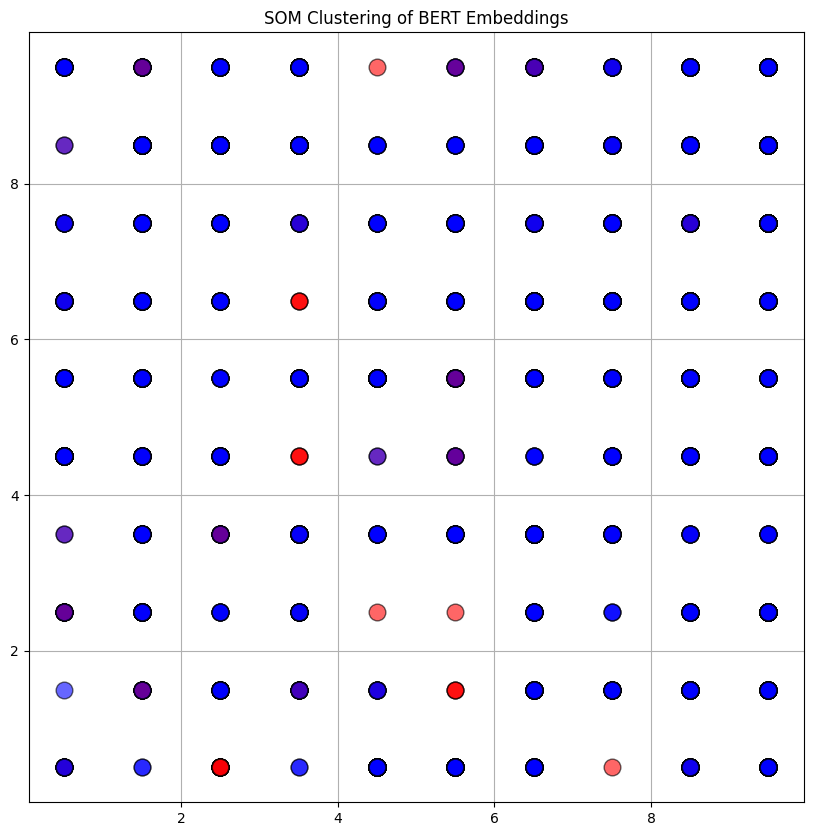

In [ ]:
# Step 4: Plot SOM
plt.figure(figsize=(10, 10))
colors = {'HillaryClinton': 'red', 'realDonaldTrump': 'blue'}
for i, emb in enumerate(embeddings):
    winner = som.winner(emb)
    plt.plot(winner[0] + 0.5, winner[1] + 0.5,
             marker='o', markerfacecolor=colors[labels[i]],
             markeredgecolor='k', markersize=12, alpha=0.6)

plt.title("SOM Clustering of BERT Embeddings")
plt.grid()
plt.show()

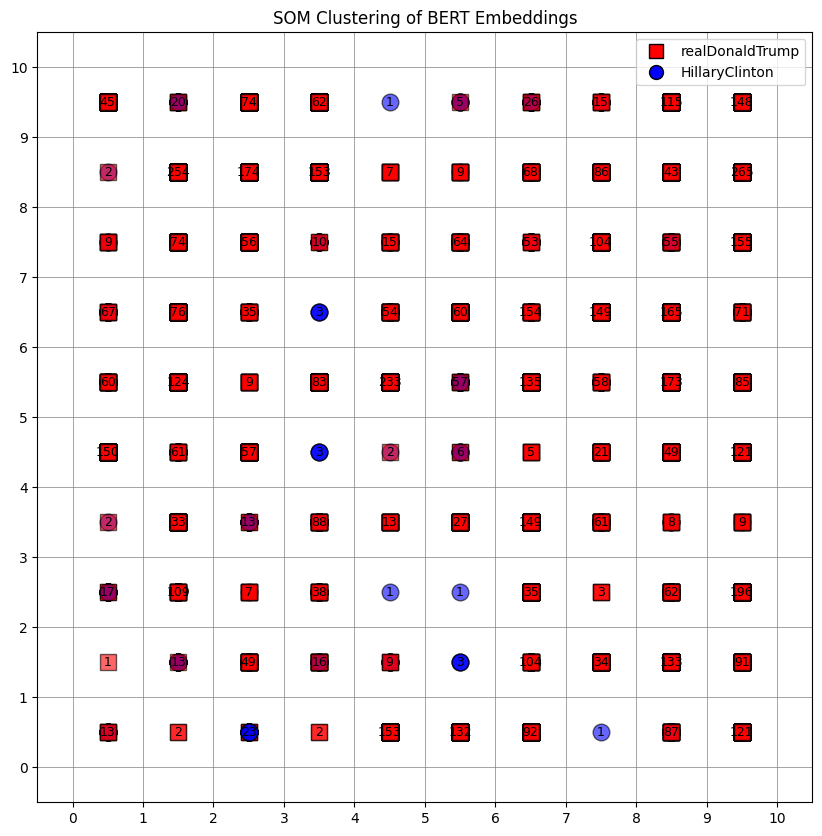

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
from collections import defaultdict

# Recompute winners
win_map = defaultdict(list)
for i, emb in enumerate(embeddings):
    win_map[som.winner(emb)].append(i)

# Define label colors and shapes
unique_labels = list(set(labels))
colors = {'HillaryClinton': 'blue', 'realDonaldTrump': 'red'}
markers = {'HillaryClinton': 'o', 'realDonaldTrump': 's'}

plt.figure(figsize=(10, 10))
plt.title("SOM Clustering of BERT Embeddings")

# Plot each point at its BMU with color and shape by label
for i, emb in enumerate(embeddings):
    x, y = som.winner(emb)
    label = labels[i]
    plt.plot(x + 0.5, y + 0.5,
             marker=markers[label],
             color=colors[label],
             markeredgecolor='k',
             markersize=12,
             alpha=0.6)

# Draw grid lines
for x in range(11):
    plt.axhline(x, color='gray', linewidth=0.5)
    plt.axvline(x, color='gray', linewidth=0.5)

# Optionally annotate count in each neuron
for position, indices in win_map.items():
    x, y = position
    plt.text(x + 0.5, y + 0.5, str(len(indices)),
             ha='center', va='center', fontsize=9, color='black')

# Add legend
legend_handles = [plt.Line2D([0], [0], marker=markers[l], color='w',
                             markerfacecolor=colors[l], markeredgecolor='k',
                             markersize=10, label=l) for l in unique_labels]
plt.legend(handles=legend_handles, loc='upper right')

plt.xticks(np.arange(11))
plt.yticks(np.arange(11))
plt.grid(False)
plt.show()


In [ ]:
from matplotlib import colors as mcolors

def plot_umatrix(som, win_map, labels, grid_size=(10,10)):
    plt.figure(figsize=(12, 6))

    # --- 1. U-Matrix (distance heatmap between SOM neurons) ---
    plt.subplot(1, 2, 1)
    umatrix = np.zeros((grid_size[0], grid_size[1]))

    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            neighbors = som.get_neighbors(i, j)
            dists = [np.linalg.norm(som._weights[i, j] - som._weights[x, y])
                     for x, y in neighbors]
            umatrix[i, j] = np.mean(dists) if dists else 0

    plt.imshow(umatrix.T, cmap='bone_r', origin='lower')
    plt.title("U-Matrix (Neuron Distance Map)")
    plt.colorbar(label='Avg Distance to Neighbors')
    plt.xticks(np.arange(grid_size[0]))
    plt.yticks(np.arange(grid_size[1]))

    # --- 2. Label Purity Heatmap ---
    plt.subplot(1, 2, 2)
    label_counts = np.empty((grid_size[0], grid_size[1]), dtype=object)
    label_purity = np.zeros((grid_size[0], grid_size[1]))

    # Set of all labels
    label_set = list(set(labels))
    label_colors = dict(zip(label_set, ['blue', 'red']))  # extend if more

    # Initialize each cell with an empty dict
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            label_counts[i, j] = {}

    # Count labels in each BMU
    for i, emb in enumerate(embeddings):
        x, y = som.winner(emb)
        label = labels[i]
        if label in label_counts[x, y]:
            label_counts[x, y][label] += 1
        else:
            label_counts[x, y][label] = 1

    # Compute majority class in each neuron and color
    purity_map = np.zeros((grid_size[0], grid_size[1], 3))
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            cell = label_counts[i, j]
            if cell:
                max_label = max(cell, key=cell.get)
                total = sum(cell.values())
                purity = cell[max_label] / total
                rgb = mcolors.to_rgb(label_colors[max_label])
                purity_map[i, j, :] = np.array(rgb) * purity

    plt.imshow(purity_map.transpose(1, 0, 2), origin='lower')
    plt.title("Label Purity Heatmap")
    plt.xticks(np.arange(grid_size[0]))
    plt.yticks(np.arange(grid_size[1]))

    legend_handles = [plt.Line2D([0], [0], marker='s', color=color, linestyle='None',
                                 markersize=10, label=label)
                      for label, color in label_colors.items()]
    plt.legend(handles=legend_handles, loc='upper right', title="Dominant Label")

    plt.tight_layout()
    plt.show()


In [ ]:
def plot_umatrix(som, win_map, labels, embeddings, grid_size=(10, 10)):
    plt.figure(figsize=(12, 6))

    # --- 1. U-Matrix ---
    plt.subplot(1, 2, 1)
    umatrix = np.zeros((grid_size[0], grid_size[1]))

    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            neighbors = [
                (x, y)
                for x in range(i - 1, i + 2)
                for y in range(j - 1, j + 2)
                if (0 <= x < grid_size[0]) and (0 <= y < grid_size[1]) and (x, y) != (i, j)
            ]
            dists = [np.linalg.norm(som._weights[i, j] - som._weights[x, y])
                     for x, y in neighbors]
            umatrix[i, j] = np.mean(dists) if dists else 0

    plt.imshow(umatrix.T, cmap='bone_r', origin='lower')
    plt.title("U-Matrix (Neuron Distance Map)")
    plt.colorbar(label='Avg Distance to Neighbors')
    plt.xticks(np.arange(grid_size[0]))
    plt.yticks(np.arange(grid_size[1]))

    # --- 2. Label Purity Heatmap ---
    plt.subplot(1, 2, 2)
    label_set = list(set(labels))
    label_colors = dict(zip(label_set, ['blue', 'red', 'green', 'purple', 'orange']))

    label_counts = np.empty((grid_size[0], grid_size[1]), dtype=object)
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            label_counts[i, j] = {}

    # Count label appearances per neuron
    for i, emb in enumerate(embeddings):
        x, y = som.winner(emb)
        label = labels[i]
        if label in label_counts[x, y]:
            label_counts[x, y][label] += 1
        else:
            label_counts[x, y][label] = 1

    # Color grid by dominant label + purity
    purity_map = np.zeros((grid_size[0], grid_size[1], 3))
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            cell = label_counts[i, j]
            if cell:
                max_label = max(cell, key=cell.get)
                total = sum(cell.values())
                purity = cell[max_label] / total
                rgb = mcolors.to_rgb(label_colors[max_label])
                purity_map[i, j, :] = np.array(rgb) * purity

    plt.imshow(purity_map.transpose(1, 0, 2), origin='lower')
    plt.title("Label Purity Heatmap")
    plt.xticks(np.arange(grid_size[0]))
    plt.yticks(np.arange(grid_size[1]))

    # Add legend
    legend_handles = [
        plt.Line2D([0], [0], marker='s', color=color, linestyle='None', markersize=10, label=label)
        for label, color in label_colors.items()
    ]
    plt.legend(handles=legend_handles, loc='upper right', title="Dominant Label")

    plt.tight_layout()
    plt.show()

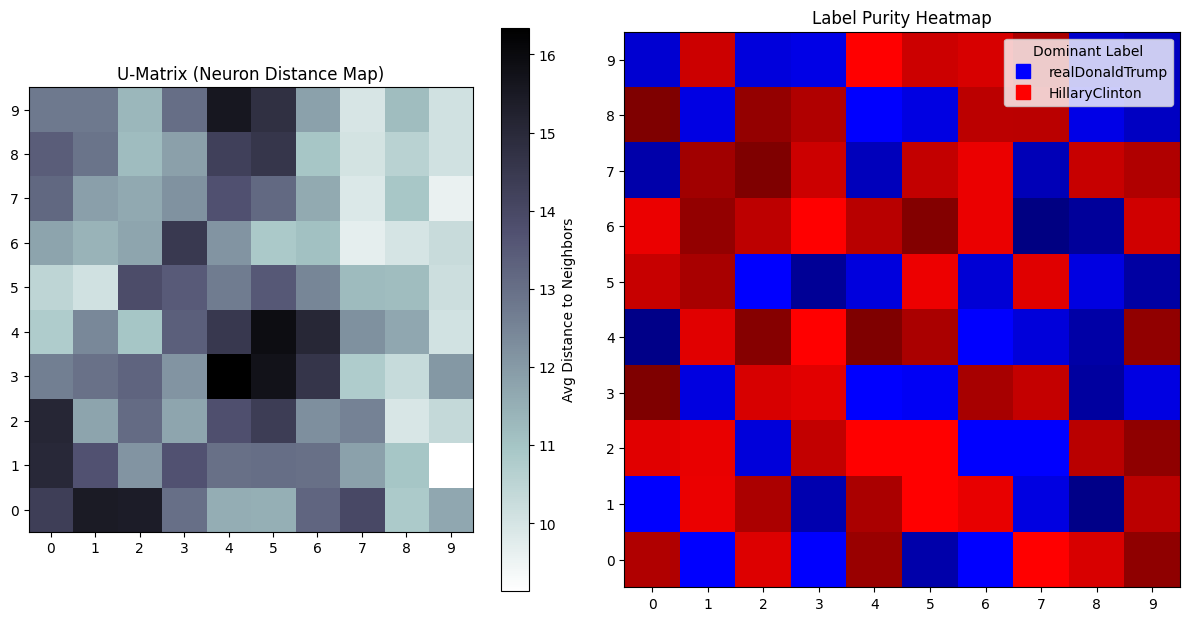

In [ ]:
from collections import defaultdict

# Create win_map if needed
win_map = defaultdict(list)
for i, emb in enumerate(embeddings):
    win_map[som.winner(emb)].append(i)

# Plot
plot_umatrix(som, win_map, labels, embeddings, grid_size=(10,10))

In [ ]:
import numpy as np
from collections import defaultdict, Counter

# Build a map from neuron to list of labels
neuron_labels = defaultdict(list)

for i, emb in enumerate(embeddings):
    winner = som.winner(emb)
    label = labels[i]
    neuron_labels[winner].append(label)

# Compute purity per neuron
neuron_purities = {}

for neuron, label_list in neuron_labels.items():
    label_counts = Counter(label_list)
    dominant_label_count = max(label_counts.values())
    total = len(label_list)
    purity = dominant_label_count / total if total > 0 else 0
    neuron_purities[neuron] = {
        "purity": round(purity, 3),
        "total": total,
        "dominant_label": label_counts.most_common(1)[0][0],
        "label_distribution": dict(label_counts)
    }

# Example output
for neuron, info in sorted(neuron_purities.items()):
    print(f"Neuron {neuron}: Purity={info['purity']}, Total={info['total']}, "
          f"Dominant={info['dominant_label']}, Distribution={info['label_distribution']}")


Neuron (np.int64(0), np.int64(0)): Purity=0.692, Total=13, Dominant=HillaryClinton, Distribution={'HillaryClinton': 9, 'realDonaldTrump': 4}
Neuron (np.int64(0), np.int64(1)): Purity=1.0, Total=1, Dominant=realDonaldTrump, Distribution={'realDonaldTrump': 1}
Neuron (np.int64(0), np.int64(2)): Purity=0.882, Total=17, Dominant=HillaryClinton, Distribution={'HillaryClinton': 15, 'realDonaldTrump': 2}
Neuron (np.int64(0), np.int64(3)): Purity=0.5, Total=2, Dominant=HillaryClinton, Distribution={'HillaryClinton': 1, 'realDonaldTrump': 1}
Neuron (np.int64(0), np.int64(4)): Purity=0.533, Total=150, Dominant=realDonaldTrump, Distribution={'realDonaldTrump': 80, 'HillaryClinton': 70}
Neuron (np.int64(0), np.int64(5)): Purity=0.783, Total=60, Dominant=HillaryClinton, Distribution={'HillaryClinton': 47, 'realDonaldTrump': 13}
Neuron (np.int64(0), np.int64(6)): Purity=0.925, Total=67, Dominant=HillaryClinton, Distribution={'HillaryClinton': 62, 'realDonaldTrump': 5}
Neuron (np.int64(0), np.int64(7

In [ ]:
pip install scikit-learn


In [ ]:
from sklearn.metrics import adjusted_rand_score, silhouette_score
from collections import defaultdict, Counter
import numpy as np

***Cluster Purity***

In [ ]:
# Map each embedding to its winning neuron
neuron_labels = defaultdict(list)

for i, emb in enumerate(embeddings):
    winner = som.winner(emb)
    neuron_labels[winner].append(labels[i])

# Compute purity per neuron
purities = []
for label_list in neuron_labels.values():
    count = Counter(label_list) # count how many of each label
    dominant = count.most_common(1)[0][1] # How many are the dominant label
    total = sum(count.values()) # Total points in this neuron
    purities.append(dominant / total) # Purity = majority / total

# Overall cluster purity
cluster_purity = round(np.mean(purities), 4)
print("Cluster Purity:", cluster_purity)

Cluster Purity: 0.7875


**Adjusted Rand Index (ARI)**

In [ ]:
from sklearn.metrics import adjusted_rand_score

# Assign each sample to its neuron's unique ID
cluster_assignments = []
for emb in embeddings:
    winner = som.winner(emb)
    cluster_id = winner[0] * som._weights.shape[1] + winner[1]  # # Create cluster IDs from neurons (e.g., neuron (2,3) → ID = 2*10 + 3 = 23)
    cluster_assignments.append(cluster_id)

ari_score = round(adjusted_rand_score(labels, cluster_assignments), 4)
print("Adjusted Rand Index (ARI):", ari_score)

Adjusted Rand Index (ARI): 0.0109


***Silhouette Score***

In [ ]:
from sklearn.metrics import silhouette_score

# Note: Needs >1 sample per cluster to be valid
if len(set(cluster_assignments)) > 1:
    sil_score = round(silhouette_score(embeddings, cluster_assignments), 4)
    print("Silhouette Score:", sil_score)
else:
    print("Silhouette Score: Not computable (only one cluster)")

Silhouette Score: -0.0005
